<a href="https://colab.research.google.com/github/Lio72rga/Mineria-de-Datos-2026/blob/main/Clase_6_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

En este notebook se aplicarán diferentes técnicas de clustering para analizar conjuntos de datos y detectar agrupamientos naturales.

Se trabajará con:

**K-Means**

**DBScan**

**Método del Codo**

Métricas de evaluación

El objetivo es comprender cómo funcionan los algoritmos de aprendizaje no supervisado y comparar sus resultados.


## 1. Importación de Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score


## 2. Generación de Datos Sintéticos

En esta sección se generará un conjunto de datos artificial con 4 grupos utilizando make_blobs.

El objetivo es visualizar cómo se distribuyen los datos antes de aplicar clustering.
# Generar dataset sintético con 4 clusters


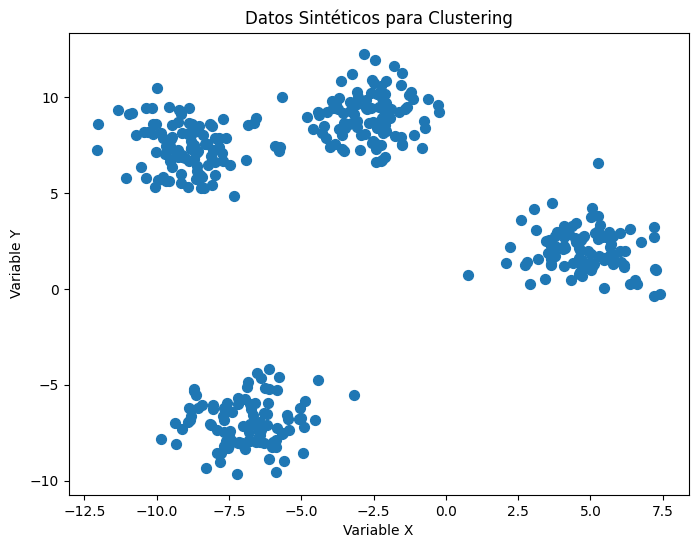

In [2]:
X, y = make_blobs(
   n_samples=400,
   centers=4,
   cluster_std=1.2,
   random_state=42
)

# Visualización de datos

plt.figure(figsize=(8,6))

plt.scatter(X[:,0], X[:,1], s=50)

plt.title("Datos Sintéticos para Clustering")
plt.xlabel("Variable X")
plt.ylabel("Variable Y")

plt.show()


## Conclusión
Se observan cuatro agrupamientos relativamente bien definidos.
Los grupos presentan una forma aproximadamente esférica, por lo que el algoritmo K-Means podría ser una buena opción para segmentar estos datos.


# 3. Aplicación de K-Means
¿Qué es K-Means?

K-Means es un algoritmo de clustering que agrupa los datos en K grupos utilizando centroides.

Cada punto se asigna al centroide más cercano.


## 3.1 Método del Codo
El método del codo permite identificar el número óptimo de clusters analizando la inercia.


In [3]:
# Lista para guardar la inercia

inercia = []

# Valores posibles de K

valores_k = range(1, 10)

# Entrenamiento del modelo para distintos valores de K

for k in valores_k:

   kmeans = KMeans(
       n_clusters=k,
       random_state=42
   )

   kmeans.fit(X)

   inercia.append(kmeans.inertia_)


## Visualización del Método del Codo


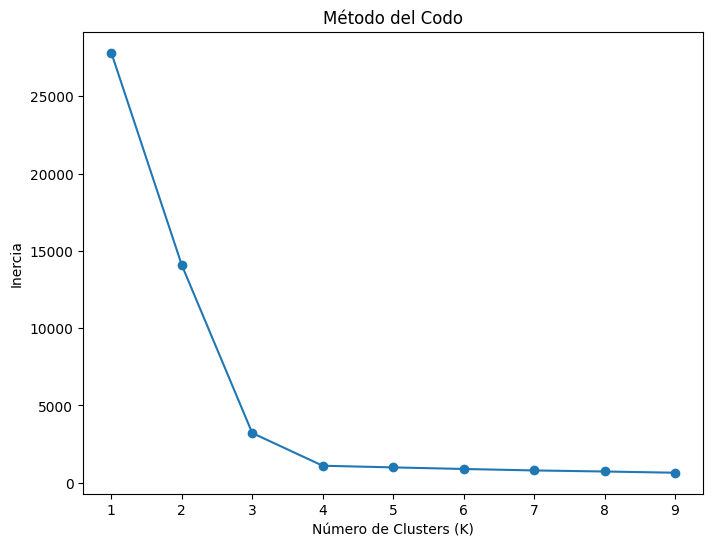

In [4]:
plt.figure(figsize=(8,6))

plt.plot(
   valores_k,
   inercia,
   marker="o",
   linestyle="-"
)

plt.xlabel("Número de Clusters (K)")
plt.ylabel("Inercia")

plt.title("Método del Codo")

plt.show()


## Interpretación
El gráfico permite observar el punto donde la reducción de la inercia comienza a disminuir más lentamente.
Ese punto representa el número óptimo de clusters.
En este caso, el codo aparece aproximadamente en K = 4.


## 3.2 Aplicación de K-Means

In [5]:
# Aplicar K-Means con 4 clusters

kmeans = KMeans(
   n_clusters=4,
   random_state=42
)

clusters_kmeans = kmeans.fit_predict(X)


## Visualización de los Clusters


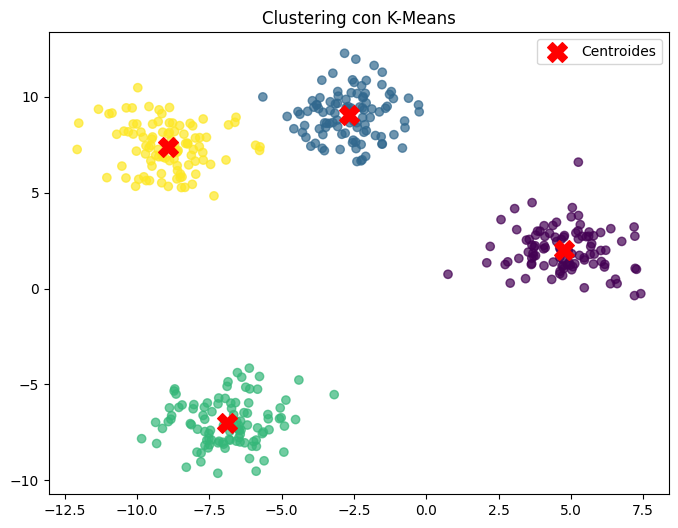

In [6]:
plt.figure(figsize=(8,6))

plt.scatter(
   X[:,0],
   X[:,1],
   c=clusters_kmeans,
   cmap="viridis",
   alpha=0.7
)

# Centroides

plt.scatter(
   kmeans.cluster_centers_[:,0],
   kmeans.cluster_centers_[:,1],
   c="red",
   marker="X",
   s=200,
   label="Centroides"
)

plt.title("Clustering con K-Means")

plt.legend()

plt.show()


## Conclusión
K-Means logró separar correctamente los grupos presentes en los datos.

Los centroides representan el centro de cada cluster y permiten visualizar la distribución de los grupos.


## Asignación de Etiquetas a los Datos

In [7]:
df_clustered = pd.DataFrame(X, columns=['Variable X', 'Variable Y'])
df_clustered['Cluster'] = clusters_kmeans
display(df_clustered.head())

,Variable X,Variable Y,Cluster
0,-10.374843,9.429276,3
1,-5.652892,10.000569,1
2,-9.133219,6.996255,3
3,5.810023,1.796701,0
4,5.324947,3.335848,0


## Asignación de Etiquetas a los Datos

In [8]:
df_clustered = pd.DataFrame(X, columns=['Variable X', 'Variable Y'])
df_clustered['Cluster'] = clusters_kmeans
display(df_clustered.head())

,Variable X,Variable Y,Cluster
0,-10.374843,9.429276,3
1,-5.652892,10.000569,1
2,-9.133219,6.996255,3
3,5.810023,1.796701,0
4,5.324947,3.335848,0


# 4. Clustering con DBScan

¿Qué es DBScan?

DBScan es un algoritmo basado en densidad que permite detectar clusters con formas complejas y encontrar outliers automáticamente.

A diferencia de K-Means:
no requiere definir K
detecta ruido
maneja mejor formas irregulares


## 4.1 Generación de Datos Curvos
Se utilizará make_moons, un dataset con forma curva donde K-Means suele fallar.

In [9]:
# Dataset con forma de media luna

X_moons, y_moons = make_moons(
   n_samples=300,
   noise=0.05,
   random_state=42
)


## Visualización Inicial


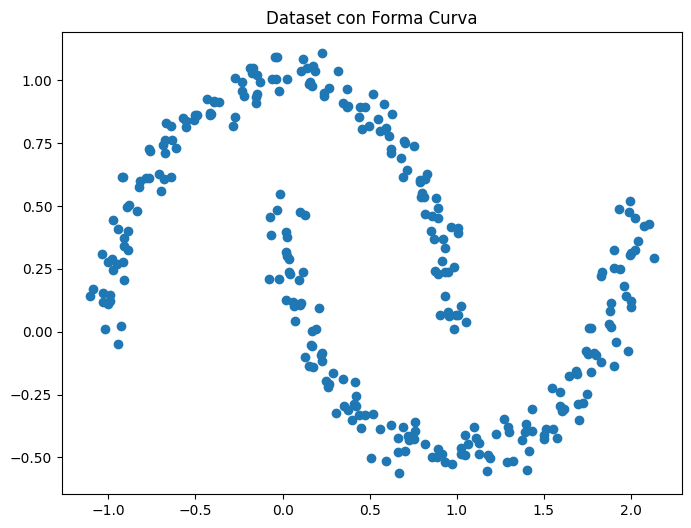

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(
   X_moons[:,0],
   X_moons[:,1]
)

plt.title("Dataset con Forma Curva")

plt.show()


## 4.2 Aplicación de DBScan


In [11]:
# Aplicar DBScan

dbscan = DBSCAN(
   eps=0.2,
   min_samples=5
)

clusters_dbscan = dbscan.fit_predict(X_moons)


## Visualización de Resultados


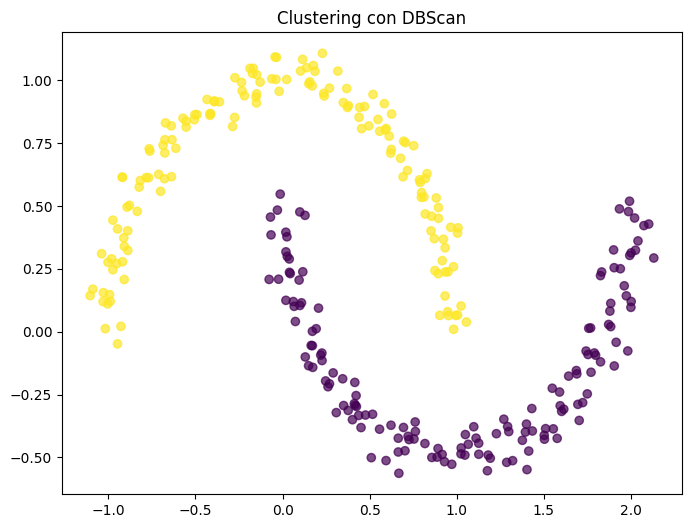

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(
   X_moons[:,0],
   X_moons[:,1],
   c=clusters_dbscan,
   cmap="viridis",
   alpha=0.7
)

plt.title("Clustering con DBScan")

plt.show()


## Interpretación
DBScan logró identificar correctamente los grupos con formas curvas.

Además, los puntos etiquetados como -1 corresponden a posibles outliers.


# 5. Comparación entre K-Means y DBScan
En esta sección se compararán ambos algoritmos utilizando el dataset Iris.


## 5.1 Carga del Dataset Iris


In [13]:
# Cargar dataset Iris

df_iris = sns.load_dataset("iris")

# Selección de variables

X_iris = df_iris[
   ["sepal_length", "sepal_width"]
].values


## 5.2 Aplicación de K-Means

In [14]:
kmeans_iris = KMeans(
   n_clusters=3,
   random_state=42
)

df_iris["Cluster_KMeans"] = kmeans_iris.fit_predict(X_iris)


## 5.3 Aplicación de DBScan

In [24]:
dbscan_iris = DBSCAN(
    eps=0.25,
    min_samples=5
)

df_iris["Cluster_DBScan"] = dbscan_iris.fit_predict(X_iris)

## Ajuste de Parámetros en DBScan

Inicialmente, DBScan detectó un único cluster, lo que impedía calcular algunas métricas de evaluación.

Para mejorar la segmentación, se ajustó el parámetro eps de 0.5 a 0.25, permitiendo detectar múltiples agrupamientos y valores atípicos de forma más adecuada.

Esto demuestra la sensibilidad de DBScan a la configuración de sus parámetros.

## 5.4 Visualización Comparativa


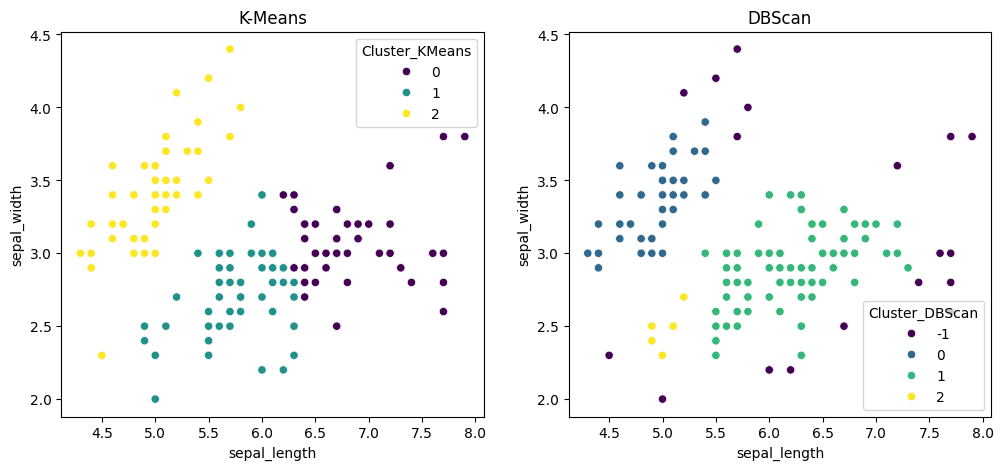

In [25]:
plt.figure(figsize=(12,5))

# K-Means

plt.subplot(1,2,1)

sns.scatterplot(
   x=df_iris["sepal_length"],
   y=df_iris["sepal_width"],
   hue=df_iris["Cluster_KMeans"],
   palette="viridis"
)

plt.title("K-Means")

# DBScan

plt.subplot(1,2,2)

sns.scatterplot(
   x=df_iris["sepal_length"],
   y=df_iris["sepal_width"],
   hue=df_iris["Cluster_DBScan"],
   palette="viridis"
)

plt.title("DBScan")

plt.show()


## Conclusión

K-Means separó los datos en 3 grupos relativamente definidos utilizando centroides.

Por otro lado, DBScan logró detectar agrupamientos basados en densidad y además identificó posibles valores atípicos etiquetados como -1.

A diferencia de K-Means, DBScan no requiere definir previamente la cantidad de clusters y puede adaptarse mejor a estructuras de datos más complejas.

Los resultados obtenidos muestran que ambos algoritmos presentan enfoques diferentes de segmentación y pueden utilizarse según las características del dataset.


# 6. Evaluación de Clustering
* Para evaluar la calidad del clustering se utilizarán:

* Silhouette Score
Davies-Bouldin Index


## 6.1 Métricas para K-Means


In [26]:
# Silhouette Score para K-Means

silhouette_kmeans = silhouette_score(
    X_iris,
    df_iris["Cluster_KMeans"]
)

# Davies-Bouldin Index para K-Means

dbi_kmeans = davies_bouldin_score(
    X_iris,
    df_iris["Cluster_KMeans"]
)

# Mostrar resultados

print("K-Means")
print("Silhouette Score:", round(silhouette_kmeans, 2))
print("Davies-Bouldin Index:", round(dbi_kmeans, 2))

K-Means
Silhouette Score: 0.45
Davies-Bouldin Index: 0.77


## Interpretación

El coeficiente de Silhouette obtenido indica que los clusters generados por K-Means presentan una separación adecuada entre grupos.

El Davies-Bouldin Index relativamente bajo sugiere que los clusters son compactos y bien diferenciados.

Estos resultados muestran que K-Means logró una segmentación eficiente para el dataset Iris.

## 6.2 Métricas para DBScan

In [27]:
# Eliminar outliers (-1)

mask = df_iris["Cluster_DBScan"] != -1

# Obtener labels válidos

labels_validos = df_iris["Cluster_DBScan"][mask]

# Ver cantidad de clusters encontrados

cantidad_clusters = len(set(labels_validos))

print("Cantidad de clusters detectados:", cantidad_clusters)

# Evaluar solo si hay más de 1 cluster

if cantidad_clusters > 1:

    silhouette_dbscan = silhouette_score(
        X_iris[mask],
        labels_validos
    )

    dbi_dbscan = davies_bouldin_score(
        X_iris[mask],
        labels_validos
    )

    print("DBScan")
    print("Silhouette Score:", round(silhouette_dbscan, 2))
    print("Davies-Bouldin Index:", round(dbi_dbscan, 2))

else:

    print("DBScan no encontró suficientes clusters para calcular métricas.")

Cantidad de clusters detectados: 3
DBScan
Silhouette Score: 0.42
Davies-Bouldin Index: 0.61


Durante la evaluación de DBScan se produjo un error debido a que el algoritmo detectó un único cluster válido.

El coeficiente de Silhouette requiere al menos dos clusters para poder calcular la separación entre grupos.

Para resolverlo, se validó previamente la cantidad de clusters detectados antes de calcular las métricas.

## Conclusión Final

En este trabajo se aplicaron diferentes técnicas de clustering para analizar agrupamientos naturales en distintos conjuntos de datos utilizando Python y Scikit-learn.

A lo largo de la actividad se implementaron los algoritmos K-Means y DBScan, permitiendo comprender sus diferencias, ventajas y limitaciones.

K-Means mostró un buen desempeño en datasets con grupos bien definidos y formas relativamente esféricas. Mediante el método del codo fue posible determinar un número adecuado de clusters y obtener segmentaciones claras y organizadas.

Por otro lado, DBScan permitió trabajar con agrupamientos basados en densidad, logrando detectar valores atípicos y estructuras más complejas. Durante el desarrollo se observó la importancia del ajuste de parámetros como eps, ya que pequeñas modificaciones pueden cambiar significativamente los resultados obtenidos.

Además, las métricas de evaluación como Silhouette Score y Davies-Bouldin Index permitieron comparar objetivamente la calidad de los clusters generados por cada algoritmo.

En conclusión, no existe un único método de clustering ideal para todos los casos. La elección del algoritmo depende de las características del dataset, la presencia de ruido, la forma de los grupos y el objetivo del análisis.